# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Thermodynamics & In Silico Biology (Ramachandran Plot)

---
*Note: I built this notebook to see how far vector calculus alone gets you before you need a chemistry package. No pre-compiled structural biology library appears anywhere below (only cross products, normalization, and two-dimensional arctangents), translating a protein's physical constraints into a density map. Geometry doing biology's job.*

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Single source of truth: the backbone parser and the dihedral geometry live in
# src/ramachandran.py (and are unit-tested there). The notebook imports them so the
# plotted angles and the tested angles are computed by the exact same code.
sys.path.insert(0, str(Path.cwd().parent / "src"))
from ramachandran import build_ramachandran, extract_backbone

plt.style.use('dark_background')
sns.set_palette("magma")
np.seterr(all='ignore')  # Ignore null division vector warnings

### 1. Ingestion of Raw Atomic Coordinates
Ramachandran's postulate reduces a protein's shape to two numbers: of the three repeating bonds in the backbone, only the $\phi$ *(Phi)* and $\psi$ *(Psi)* angles are free to rotate. The third, the peptide bond $\omega$ *(Omega)*, is locked flat by its partial double-bond character — a bond that behaves like it has already decided.

I extract the coordinates of the three backbone atoms that carry this story: Nitrogen (N), Alpha Carbon (CA), and Carboxyl Carbon (C).

In [ ]:
df_backbone = extract_backbone('../data/1aho.pdb')
print(f"[*] Backbone extracted: {len(df_backbone)} atomic vectors.")
df_backbone.head()

### 2. Dihedral Algorithmic Engine (Vector Calculus)
I formalize the dihedral angle between four atoms $(p_0, p_1, p_2, p_3)$, built from three bond vectors $(b_1, b_2, b_3)$, as the angle between two planes: one tilted by $b_1$ and $b_2$, the other by $b_2$ and $b_3$.

$\text{Dih}(p_1, p_2, p_3, p_4) = \text{atan2}(|b_2| b_1 \cdot (b_2 \times b_3), (b_1 \times b_2) \cdot (b_2 \times b_3))$

In [ ]:
phis, psis = build_ramachandran(df_backbone)
print(f"[*] Computed {len(phis)} dihedral angle pairs (Phi, Psi).")

### 3. Thermodynamic Visualization: The Ramachandran Plot
I feed the output of that vector algebra into a density hexbin. The white zones are where atoms would collide — conformations the geometry simply forbids. By contrast, the warm clusters are where alpha helices and beta sheets actually live: not a theoretical claim, just where the angles pile up.

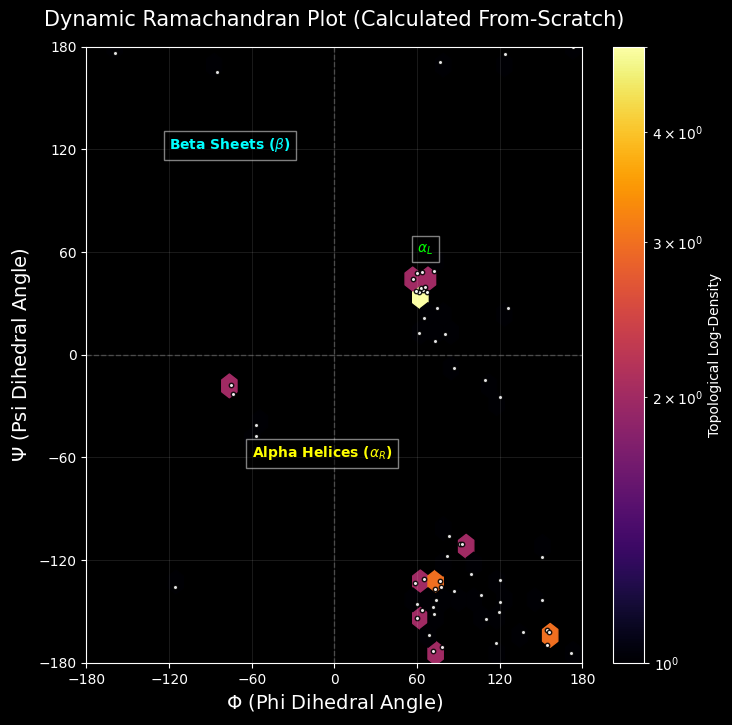

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))

# Hexbin for density
hb = ax.hexbin(phis, psis, gridsize=30, cmap='inferno', mincnt=1, bins='log')
ax.scatter(phis, psis, color='white', edgecolor='black', s=10, alpha=0.9)

ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_xticks(np.arange(-180, 181, 60))
ax.set_yticks(np.arange(-180, 181, 60))

ax.set_xlabel(r'$\Phi$ (Phi Dihedral Angle)', fontsize=14)
ax.set_ylabel(r'$\Psi$ (Psi Dihedral Angle)', fontsize=14)
ax.set_title("Dynamic Ramachandran Plot (Calculated From-Scratch)", fontsize=15, pad=15)

# Annotations for Secondary Structures (Typical regions)
ax.text(-120, 120, r"Beta Sheets ($\beta$)", color="cyan", fontsize=10, fontweight="bold", bbox=dict(facecolor='black', alpha=0.5))
ax.text(-60, -60, r"Alpha Helices ($\alpha_R$)", color="yellow", fontsize=10, fontweight="bold", bbox=dict(facecolor='black', alpha=0.5))
ax.text(60, 60, r"$\alpha_L$", color="lime", fontsize=10, fontweight="bold", bbox=dict(facecolor='black', alpha=0.5))

plt.colorbar(hb, ax=ax, label="Topological Log-Density")
plt.grid(alpha=0.1)
plt.show()